<a href="https://colab.research.google.com/github/NamrathaC740/Ai-insta-detect/blob/main/E_commerce_sales_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error


In [ ]:
df = pd.read_csv("/content/Ecommerce_Sales_Data_2024_2025 (1).csv")



In [ ]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [ ]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5000
Columns: 14


In [ ]:
df.isna().sum()

,0
Order ID,0
Order Date,0
Customer Name,0
Region,0
City,0
Category,0
Sub-Category,0
Product Name,0
Quantity,0
Unit Price,0


In [ ]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y-%m-%d')

In [ ]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Oredr Day of Week'] = df['Order Date'].dt.dayofweek

In [ ]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Order Month,Order Year,Oredr Day of Week
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,10,2024,5
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,8,2025,5
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,11,2023,5
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI,5,2025,4
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card,1,2025,6


In [ ]:
df['Order Day of Week'] = df['Order Date'].dt.dayofweek
df = df.drop(columns=['Oredr Day of Week'], errors='ignore')

In [ ]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Order Month,Order Year,Order Day of Week
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,10,2024,5
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,8,2025,5
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,11,2023,5
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI,5,2025,4
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card,1,2025,6


In [ ]:
new_dataset_features = [
    'Region','City','Category','Sub-Category',
    'Quantity','Unit Price','Discount','Profit',
    'Payment Mode','Order Month','Order Year','Order Day of Week'
]
X = df[new_dataset_features].copy()
Y = df['Sales']



In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,Quantity,Unit Price,Discount,Profit,Order Month,Order Year,Order Day of Week,Region_North,Region_South,Region_West,...,Sub-Category_Textbook,Sub-Category_Vase,Sub-Category_Wall Art,Sub-Category_Wheat,Sub-Category_Women's Wear,Sub-Category_Yoga Mat,Payment Mode_Credit Card,Payment Mode_Debit Card,Payment Mode_Net Banking,Payment Mode_UPI
0,2,36294,5,10525.09,10,2024,5,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,1,42165,20,6299.66,8,2025,5,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,4,64876,20,19850.27,11,2023,5,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,5,37320,15,36311.02,5,2025,4,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1,50037,10,9050.04,1,2025,6,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
model_data = X.copy()

model_data.head()
model_data.shape

(5000, 91)

In [ ]:
target = 'Sales'

X = df.drop(columns=[target])
Y = df[target]

In [ ]:
print(X)


      Order ID Order Date      Customer Name Region       City     Category  \
0        10001 2024-10-19       Kashvi Varty  South  Bangalore        Books   
1        10002 2025-08-30        Advik Desai  North      Delhi    Groceries   
2        10003 2023-11-04         Rhea Kalla   East      Patna      Kitchen   
3        10004 2025-05-23          Anika Sen   East    Kolkata    Groceries   
4        10005 2025-01-19        Akarsh Kaul   West       Pune     Clothing   
...        ...        ...                ...    ...        ...          ...   
4995     14996 2024-06-25   Nishith Kulkarni   East    Kolkata        Books   
4996     14997 2024-12-22      Aaina Chander  North     Jaipur         Toys   
4997     14998 2025-04-15       Dhanush Gara  South  Bangalore       Beauty   
4998     14999 2024-07-08  Divyansh Malhotra   East    Kolkata  Electronics   
4999     15000 2024-02-04       Aarush Walla   West        Goa     Clothing   

     Sub-Category         Product Name  Quantity  U

In [ ]:
print(Y)

0        68958.6
1        33732.0
2       207603.2
3       158610.0
4        45033.3
          ...   
4995    182013.0
4996    350240.0
4997     35837.7
4998     48844.8
4999     69085.8
Name: Sales, Length: 5000, dtype: float64


In [ ]:
X = X.drop(columns=[
    'Order ID',
    'Customer Name',
    'Product Name',
    'Order Date'
], errors='ignore')

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
print(X.shape,X_train.shape,X_test.shape)

(5000, 91) (4000, 91) (1000, 91)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, Y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")
print("R2 Score:", r2_score(Y_test, lr_pred))
print("MSE:", mean_squared_error(Y_test, lr_pred))
print("MAE:", mean_absolute_error(Y_test, lr_pred))

Linear Regression
R2 Score: 0.9057861890735717
MSE: 716150022.2385247
MAE: 20478.94057756731


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, Y_train)

dt_pred = dt.predict(X_test)

print("\nDecision Tree")
print("R2 Score:", r2_score(Y_test, dt_pred))
print("MSE:", mean_squared_error(Y_test, dt_pred))
print("MAE:", mean_absolute_error(Y_test, dt_pred))


Decision Tree
R2 Score: 0.9619529314191071
MSE: 289208224.8068136
MAE: 12159.398076108231


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest")
print("R2 Score:", r2_score(Y_test, rf_pred))
print("MSE:", mean_squared_error(Y_test, rf_pred))
print("MAE:", mean_absolute_error(Y_test, rf_pred))


Random Forest
R2 Score: 0.9970580582317279
MSE: 22362662.56565948
MAE: 3089.221298999998


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7, weights='distance')
knn.fit(X_train_pca, Y_train)

knn_pred = knn.predict(X_test_pca)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Model Evaluation")

print("R2 Score:", r2_score(Y_test, knn_pred))
print("MSE:", mean_squared_error(Y_test, knn_pred))
print("MAE:", mean_absolute_error(Y_test, knn_pred))

Model Evaluation
R2 Score: 0.6606682678587401
MSE: 2579371592.440614
MAE: 39003.677721770815


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

results = {
    "Model": ["Random Forest", "KNN"],
    "R2 Score": [
        r2_score(Y_test, rf_pred),
        r2_score(Y_test, knn_pred)
    ],
    "MSE": [
        mean_squared_error(Y_test, rf_pred),
        mean_squared_error(Y_test, knn_pred)
    ],
    "MAE": [
        mean_absolute_error(Y_test, rf_pred),
        mean_absolute_error(Y_test, knn_pred)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

           Model  R2 Score           MSE           MAE
0  Random Forest  0.997058  2.236266e+07   3089.221299
1            KNN  0.660668  2.579372e+09  39003.677722


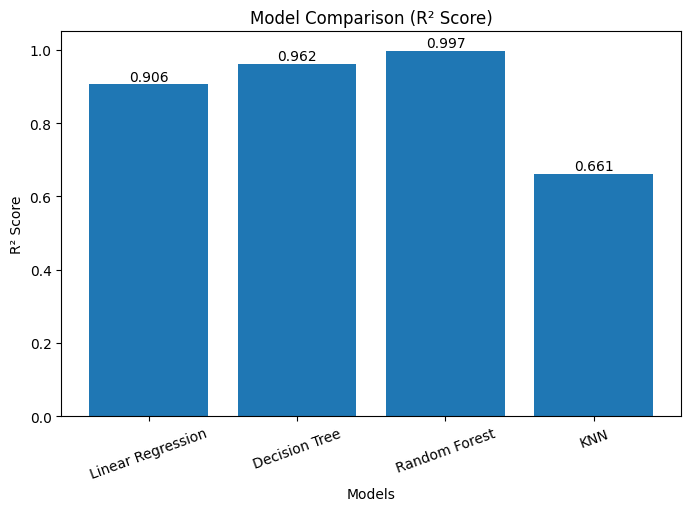

In [ ]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest", "KNN"]
r2_scores = [0.9057, 0.9619, 0.9970, 0.6606]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, str(round(v,3)), ha='center')

plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.show()

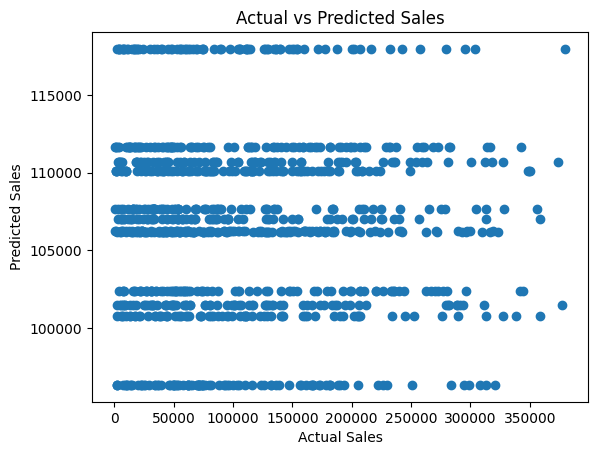

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np


df['Month'] = df['Order Date'].dt.month

X = df[['Month']]
y = df['Sales']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


rf = RandomForestRegressor()
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


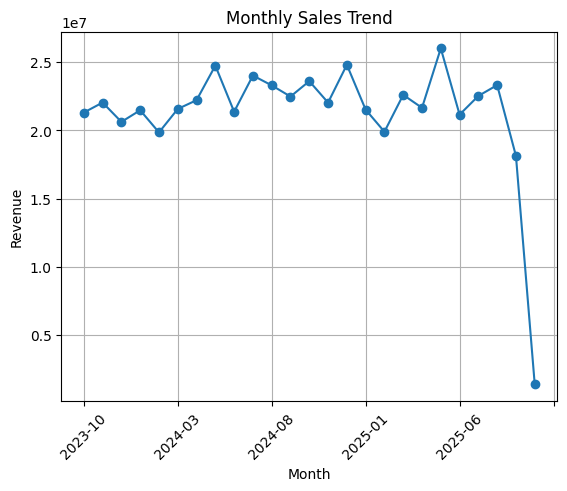

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df['Order Date'] = pd.to_datetime(df['Order Date'])


monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure()
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()


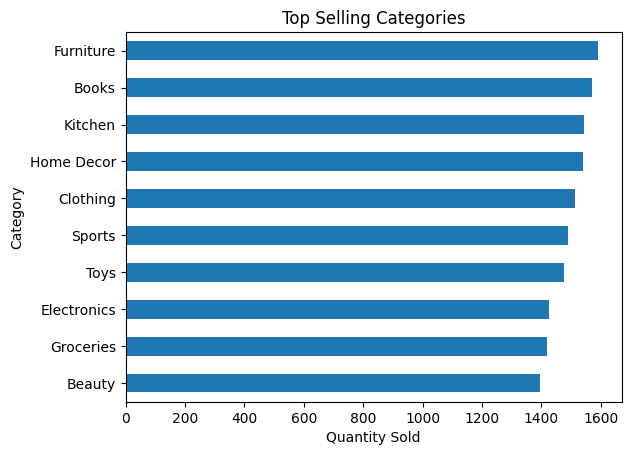

In [ ]:
category_demand = df.groupby('Category')['Quantity'].sum().sort_values()

plt.figure()
category_demand.plot(kind='barh')
plt.title("Top Selling Categories")
plt.xlabel("Quantity Sold")
plt.show()


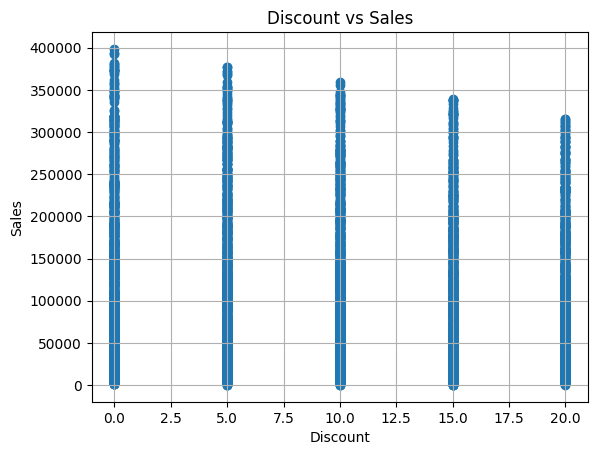

In [ ]:
plt.figure()
plt.scatter(df['Discount'], df['Sales'])
plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.grid()
plt.show()


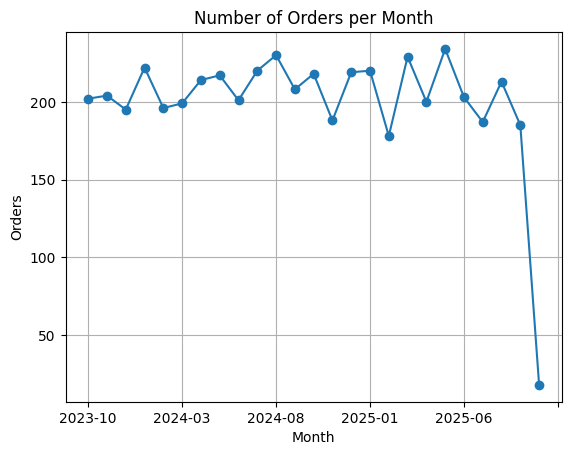

In [ ]:
orders = df.groupby(df['Order Date'].dt.to_period('M')).size()
orders.index = orders.index.astype(str)

plt.figure()
orders.plot(marker='o')
plt.title("Number of Orders per Month")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.grid()
plt.show()


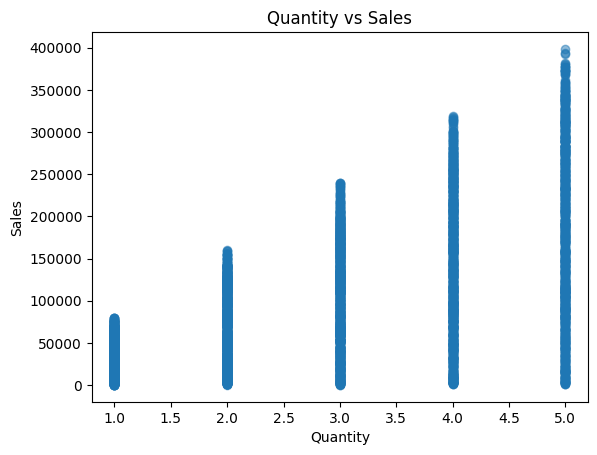

In [ ]:
plt.scatter(df['Quantity'], df['Sales'], alpha=0.5)
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

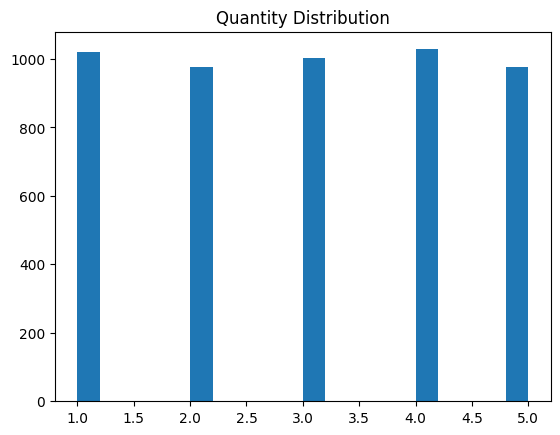

In [ ]:
plt.hist(df['Quantity'], bins=20)
plt.title("Quantity Distribution")
plt.show()

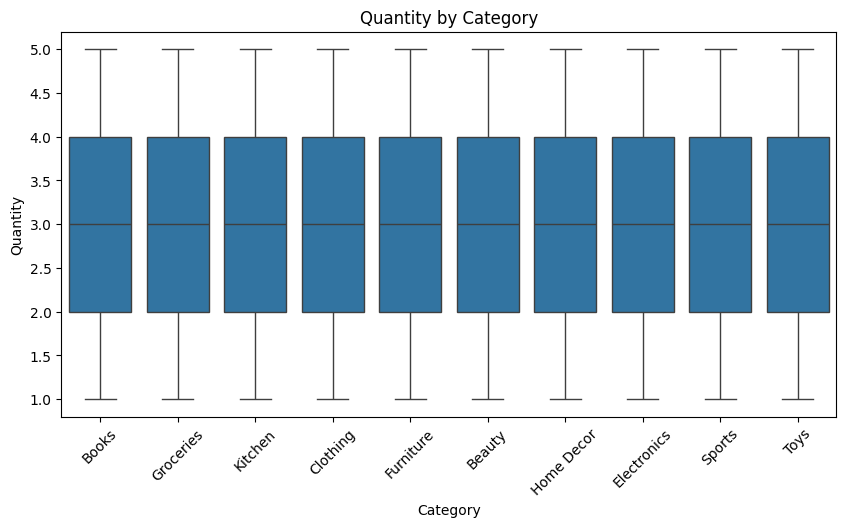

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x='Category', y='Quantity', data=df)
plt.title("Quantity by Category")
plt.xticks(rotation=45)

plt.show()

Dataset Shape: (5000, 14)
   Order ID  Order Date Customer Name Region       City   Category  \
0     10001  2024-10-19  Kashvi Varty  South  Bangalore      Books   
1     10002  2025-08-30   Advik Desai  North      Delhi  Groceries   
2     10003  2023-11-04    Rhea Kalla   East      Patna    Kitchen   
3     10004  2025-05-23     Anika Sen   East    Kolkata  Groceries   
4     10005  2025-01-19   Akarsh Kaul   West       Pune   Clothing   

  Sub-Category       Product Name  Quantity  Unit Price  Discount     Sales  \
0  Non-Fiction  Non-Fiction Ipsum         2       36294         5   68958.6   
1         Rice          Rice Nemo         1       42165        20   33732.0   
2       Juicer        Juicer Odio         4       64876        20  207603.2   
3          Oil      Oil Doloribus         5       37320        15  158610.0   
4    Kids Wear      Kids Wear Quo         1       50037        10   45033.3   

     Profit Payment Mode  
0  10525.09   Debit Card  
1   6299.66   Debit Card

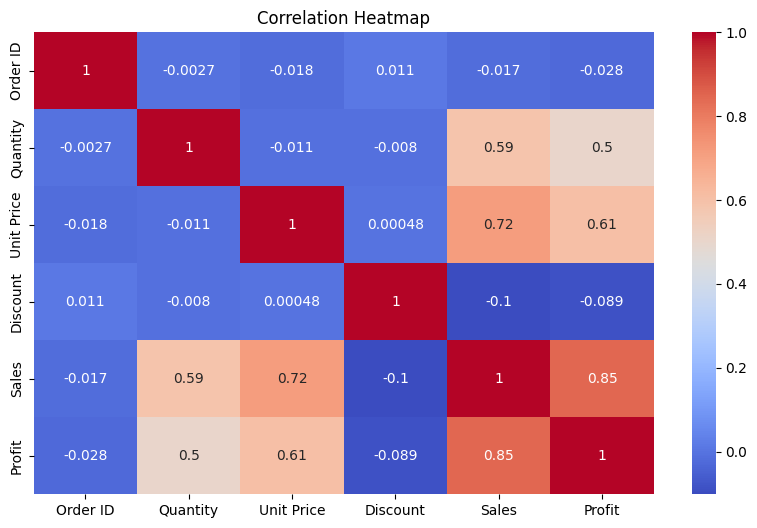

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Ecommerce_Sales_Data_2024_2025 (1).csv")
print("Dataset Shape:", df.shape)
print(df.head())

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ---------------- PAGE CONFIG ----------------

st.set_page_config(page_title="Dashboard", layout="wide")

# ---------------- STYLE ----------------

st.markdown("""
<style>

.block-container {
    padding-top: 1.5rem;
}

.kpi-box {
    background-color: #111827;
    padding: 15px;
    border-radius: 12px;
    text-align: center;
    color: white;
}

.kpi-title {
    font-size: 14px;
    color: #9CA3AF;
}

.kpi-value {
    font-size: 26px;
    font-weight: bold;
}

</style>
""", unsafe_allow_html=True)

# ---------------- LOAD DATA ----------------

df = pd.read_csv("/content/Ecommerce_Sales_Data_2024_2025 (1).csv")

df['Order Date'] = pd.to_datetime(df['Order Date'])

# ---------------- SIDEBAR ----------------

st.sidebar.title("Sales Analysis")

date_range = st.sidebar.date_input(
    "Date Range",
    [df['Order Date'].min(), df['Order Date'].max()]
)

category = st.sidebar.selectbox(
    "Category",
    ["All"] + list(df['Category'].unique())
)

region = st.sidebar.selectbox(
    "Region",
    ["All"] + list(df['Region'].unique())
)

payment = st.sidebar.selectbox(
    "Payment",
    ["All"] + list(df['Payment Mode'].unique())
)

predict_btn = st.sidebar.button("🔮 Predict Sales")

# ---------------- FILTER DATA ----------------

filtered_df = df.copy()

if len(date_range) == 2:

    filtered_df = filtered_df[
        (filtered_df['Order Date'] >= pd.to_datetime(date_range[0])) &
        (filtered_df['Order Date'] <= pd.to_datetime(date_range[1]))
    ]

if category != "All":

    filtered_df = filtered_df[
        filtered_df['Category'] == category
    ]

if region != "All":

    filtered_df = filtered_df[
        filtered_df['Region'] == region
    ]

if payment != "All":

    filtered_df = filtered_df[
        filtered_df['Payment Mode'] == payment
    ]

# ---------------- TITLE ----------------

st.markdown(
    "<h1 style='text-align:center;'> E-Commerce Sales Prediction </h1>",
    unsafe_allow_html=True
)

# ---------------- KPI SECTION ----------------

k1, k2, k3, k4 = st.columns(4)

def kpi(col, title, value):

    col.markdown(f"""
    <div class="kpi-box">
        <div class="kpi-title">{title}</div>
        <div class="kpi-value">{value}</div>
    </div>
    """, unsafe_allow_html=True)

kpi(k1, " Sales", f"{filtered_df['Sales'].sum():,.0f}")

kpi(k2, " Profit", f"{filtered_df['Profit'].sum():,.0f}")

kpi(k3, " Orders", filtered_df['Order ID'].nunique())

kpi(k4, " Quantity", filtered_df['Quantity'].sum())

st.markdown("---")

# ---------------- SALES TREND ----------------

col1, col2 = st.columns(2)

with col1:

    st.subheader(" Sales Trend")

    monthly_sales = filtered_df.groupby(
        filtered_df['Order Date'].dt.to_period('M')
    )['Sales'].sum()

    monthly_sales.index = monthly_sales.index.astype(str)

    fig1, ax1 = plt.subplots(figsize=(8,4))

    ax1.plot(
        monthly_sales.index,
        monthly_sales.values,
        marker='o',
        linewidth=3
    )

    ax1.fill_between(
        monthly_sales.index,
        monthly_sales.values,
        alpha=0.2
    )

    ax1.set_xlabel("Month")

    ax1.set_ylabel("Sales")

    ax1.grid(True)

    plt.xticks(rotation=45)

    st.pyplot(fig1)

# ---------------- TOP PRODUCTS ----------------

with col2:

    st.subheader(" Top Products")

    top_products = filtered_df.groupby(
        'Product Name'
    )['Quantity'].sum().nlargest(6)

    fig2, ax2 = plt.subplots(figsize=(7,4))

    colors = plt.cm.Set3(range(len(top_products)))

    ax2.barh(
        top_products.index,
        top_products.values,
        color=colors
    )

    ax2.invert_yaxis()

    st.pyplot(fig2)

st.markdown("---")

# ---------------- ACTUAL VS PREDICTED ----------------

col3, col4 = st.columns(2)

monthly2 = filtered_df.groupby(
    filtered_df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

if len(monthly2) > 1:

    monthly2['Month_Index'] = range(len(monthly2))

    X = monthly2[['Month_Index']]

    y = monthly2['Sales']

    model = LinearRegression()

    model.fit(X, y)

    pred = model.predict(X)

    with col3:

        st.subheader(" Actual vs Predicted")

        fig3, ax3 = plt.subplots(figsize=(7,4))

        ax3.plot(
            y.values,
            label="Actual",
            linewidth=3
        )

        ax3.plot(
            pred,
            linestyle='--',
            linewidth=3,
            label="Predicted"
        )

        ax3.legend()

        ax3.grid(True)

        st.pyplot(fig3)

# ---------------- PAYMENT MODE ----------------

with col4:

    st.subheader(" Payment Mode")

    fig4, ax4 = plt.subplots(figsize=(5,4))

    filtered_df['Payment Mode'].value_counts().plot.pie(
        autopct='%1.1f%%',
        ax=ax4
    )

    ax4.set_ylabel("")

    st.pyplot(fig4)

st.markdown("---")

# ---------------- PROFIT BY CATEGORY ----------------

col5, col6 = st.columns(2)

with col5:

    st.subheader(" Profit by Category")

    profit_category = filtered_df.groupby(
        'Category'
    )['Profit'].sum()

    fig5, ax5 = plt.subplots(figsize=(7,4))

    colors = plt.cm.tab10(range(len(profit_category)))

    ax5.bar(
        profit_category.index,
        profit_category.values,
        color=colors
    )

    ax5.set_xlabel("Category")

    ax5.set_ylabel("Profit")

    plt.xticks(rotation=20)

    st.pyplot(fig5)

# ---------------- REGION WISE SALES TREND ----------------

with col6:

    st.subheader(" Region Wise Sales Trend")

    # Tabs like Daily / Monthly / Weekly / Yearly
    trend_type = st.radio(
        "",
        ["Daily", "Monthly", "Weekly", "Yearly"],
        horizontal=True
    )

    temp_df = filtered_df.copy()

    # ---------------- GROUPING ----------------

    if trend_type == "Daily":

        region_data = temp_df.groupby(
            [
                temp_df['Order Date'].dt.strftime('%Y-%m-%d'),
                'Region'
            ]
        )['Sales'].sum().reset_index()

        x_col = 'Order Date'

    elif trend_type == "Weekly":

        region_data = temp_df.groupby(
            [
                temp_df['Order Date'].dt.to_period('W').astype(str),
                'Region'
            ]
        )['Sales'].sum().reset_index()

        x_col = 'Order Date'

    elif trend_type == "Monthly":

        region_data = temp_df.groupby(
            [
                temp_df['Order Date'].dt.to_period('M').astype(str),
                'Region'
            ]
        )['Sales'].sum().reset_index()

        x_col = 'Order Date'

    else:

        region_data = temp_df.groupby(
            [
                temp_df['Order Date'].dt.year.astype(str),
                'Region'
            ]
        )['Sales'].sum().reset_index()

        x_col = 'Order Date'

    # ---------------- PIVOT ----------------

    pivot_df = region_data.pivot(
        index=x_col,
        columns='Region',
        values='Sales'
    ).fillna(0)

    # ---------------- PLOT ----------------

    fig6, ax6 = plt.subplots(figsize=(9,4))

    for region_name in pivot_df.columns:

        ax6.plot(
            pivot_df.index,
            pivot_df[region_name],
            linewidth=2,
            label=region_name
        )

        ax6.fill_between(
            pivot_df.index,
            pivot_df[region_name],
            alpha=0.15
        )

    ax6.set_xlabel(trend_type)

    ax6.set_ylabel("Sales")

    ax6.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        ncol=4
    )

    ax6.grid(True)

    plt.xticks(rotation=45)

    st.pyplot(fig6)

# ---------------- FUTURE SALES FORECAST ----------------

if predict_btn:

    st.subheader(" Future Sales Forecast by Category")

    cat_df = df.groupby(
        [df['Order Date'].dt.to_period('M'), 'Category']
    )['Sales'].sum().reset_index()

    results = []

    for cat in cat_df['Category'].unique():

        temp = cat_df[
            cat_df['Category'] == cat
        ].copy()

        if len(temp) < 2:
            continue

        temp['Month_Index'] = range(len(temp))

        X = temp[['Month_Index']]

        y = temp['Sales']

        model = LinearRegression()

        model.fit(X, y)

        future = pd.DataFrame({
            'Month_Index': range(len(temp), len(temp)+6)
        })

        pred = model.predict(future)

        results.append({
            "Category": cat,
            "Sales": int(sum(pred))
        })

    result_df = pd.DataFrame(results)

    result_df = result_df.sort_values(
        by="Sales",
        ascending=False
    )

    fig7, ax7 = plt.subplots(figsize=(8,4))

    colors = plt.cm.tab20(range(len(result_df)))

    ax7.bar(
        result_df["Category"],
        result_df["Sales"],
        color=colors
    )

    ax7.set_xlabel("Category")

    ax7.set_ylabel("Predicted Sales")

    plt.xticks(rotation=30)

    st.pyplot(fig7)

st.markdown("---")

# ---------------- FOOTER ----------------

st.markdown(
    "<p style='text-align:center;color:gray;'>E-Commerce Dashboard</p>",
    unsafe_allow_html=True
)

Writing app.py


In [ ]:
!ngrok config add-authtoken 3CvqJdCROlhWGT3e9nkzwBEdSHZ_2e3Z3r4qqxdNWnJ3Mp6XC


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("Open this link:", public_url)

!streamlit run app.py &


Open this link: NgrokTunnel: "https://hurled-juvenile-diminish.ngrok-free.dev" -> "http://localhost:8501"


2026-05-18 07:24:29.361 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.135.37.3:8501

2026-05-18 07:24:44.452 `label` got an empty value. This is discouraged for accessibility reasons and may be disallowed in the future by raising an exception. Please provide a non-empty label and hide it with label_visibility if needed.
Stack (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1032, in _bootstrap
    self._bootstrap_inner()
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/script_runner.py",